In [5]:
#import kagglehub
import os

dataset_path = "C:/Users/Zayd_/Desktop/CV Proj/dataset"

In [7]:
import warnings
warnings.filterwarnings('ignore')

In [9]:
# Look for CSV files
metadata_files = []
for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.endswith((".csv", ".txt", ".json")):
            metadata_files.append(os.path.join(root, file))

print("\n CSV files found:")
for f in metadata_files:
        print("-", f)



 CSV files found:
- C:/Users/Zayd_/Desktop/CV Proj/dataset\csvTestImages 3360x1024.csv
- C:/Users/Zayd_/Desktop/CV Proj/dataset\csvTestLabel 3360x1.csv
- C:/Users/Zayd_/Desktop/CV Proj/dataset\csvTrainImages 13440x1024.csv
- C:/Users/Zayd_/Desktop/CV Proj/dataset\csvTrainLabel 13440x1.csv
- C:/Users/Zayd_/Desktop/CV Proj/dataset\Arabic Handwritten Characters Dataset CSV\csvTestImages 3360x1024.csv
- C:/Users/Zayd_/Desktop/CV Proj/dataset\Arabic Handwritten Characters Dataset CSV\csvTestLabel 3360x1.csv
- C:/Users/Zayd_/Desktop/CV Proj/dataset\Arabic Handwritten Characters Dataset CSV\csvTrainImages 13440x1024.csv
- C:/Users/Zayd_/Desktop/CV Proj/dataset\Arabic Handwritten Characters Dataset CSV\csvTrainLabel 13440x1.csv


In [11]:
# List top-level files and folders
top_files = os.listdir(dataset_path)
print("Top-level contents of the dataset folder:")
for f in top_files:
    print("-", f)


Top-level contents of the dataset folder:
- .ipynb_checkpoints
- Arabic Handwritten Characters Dataset CSV
- csvTestImages 3360x1024.csv
- csvTestLabel 3360x1.csv
- csvTrainImages 13440x1024.csv
- csvTrainLabel 13440x1.csv
- cv_project_code.ipynb
- Test Images 3360x32x32
- Train Images 13440x32x32
- Train+Test Images Matlab.mat


In [15]:
# Define folder paths
folder1_train = "./Train Images 13440x32x32/train"
#folder2_train = "/content/ahcd1/train images 13440x32x32/train"

folder1_test = "./Test Images 3360x32x32/test"
#folder2_test = "/content/ahcd1/test images 3360x32x32/test"

# Count files
def count_files(folder):
    return len([f for f in os.listdir(folder) if os.path.isfile(os.path.join(folder, f))])

print("Train folder 1 file count:", count_files(folder1_train))
#print("Train folder 2 file count:", count_files(folder2_train))

print("Test folder 1 file count:", count_files(folder1_test))
#print("Test folder 2 file count:", count_files(folder2_test))

# Compare file names
train_files_1 = set(os.listdir(folder1_train))
#train_files_2 = set(os.listdir(folder2_train))

test_files_1 = set(os.listdir(folder1_test))
#test_files_2 = set(os.listdir(folder2_test))

#print("\n Train folder filenames identical?", train_files_1 == train_files_2)
#print(" Test folder filenames identical?", test_files_1 == test_files_2)


Train folder 1 file count: 13440
Test folder 1 file count: 3360


In [75]:
'''import hashlib

def get_md5(file_path):
    with open(file_path, 'rb') as f:
        return hashlib.md5(f.read()).hexdigest()

def compare_folder_hashes(folder1, folder2):
    files1 = sorted(os.listdir(folder1))
    files2 = sorted(os.listdir(folder2))
    if files1 != files2:
        return False  # Different filenames

    for f in files1:
        hash1 = get_md5(os.path.join(folder1, f))
        hash2 = get_md5(os.path.join(folder2, f))
        if hash1 != hash2:
            print(f" File {f} differs.")
            return False
    return True

print("\n Comparing actual train image contents:")
identical_train = compare_folder_hashes(folder1_train, folder2_train)
print(" Train folders are identical?" , identical_train)

print("\n Comparing actual test image contents:")
identical_test = compare_folder_hashes(folder1_test, folder2_test)
print(" Test folders are identical?" , identical_test)'''


'import hashlib\n\ndef get_md5(file_path):\n    with open(file_path, \'rb\') as f:\n        return hashlib.md5(f.read()).hexdigest()\n\ndef compare_folder_hashes(folder1, folder2):\n    files1 = sorted(os.listdir(folder1))\n    files2 = sorted(os.listdir(folder2))\n    if files1 != files2:\n        return False  # Different filenames\n\n    for f in files1:\n        hash1 = get_md5(os.path.join(folder1, f))\n        hash2 = get_md5(os.path.join(folder2, f))\n        if hash1 != hash2:\n            print(f" File {f} differs.")\n            return False\n    return True\n\nprint("\n Comparing actual train image contents:")\nidentical_train = compare_folder_hashes(folder1_train, folder2_train)\nprint(" Train folders are identical?" , identical_train)\n\nprint("\n Comparing actual test image contents:")\nidentical_test = compare_folder_hashes(folder1_test, folder2_test)\nprint(" Test folders are identical?" , identical_test)'

In [17]:
import pandas as pd

# Load training data
x_train = pd.read_csv("./csvTrainImages 13440x1024.csv", header=None)
y_train = pd.read_csv("./csvTrainLabel 13440x1.csv", header=None)

# Load testing data
x_test = pd.read_csv("./csvTestImages 3360x1024.csv", header=None)
y_test = pd.read_csv("./csvTestLabel 3360x1.csv", header=None)


Training set (x_train_final)➤Used by the model to learn

Test set (x_test)➤Remains untouched until final evaluation

In [19]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13440 entries, 0 to 13439
Columns: 1024 entries, 0 to 1023
dtypes: int64(1024)
memory usage: 105.0 MB


In [21]:
y_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13440 entries, 0 to 13439
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   0       13440 non-null  int64
dtypes: int64(1)
memory usage: 105.1 KB


In [23]:
# Create a summary table
data_summary = {
    "Dataset Part": ["x_train", "y_train", "x_test", "y_test"],
    "Shape (Rows x Columns)": [
        x_train.shape,
        y_train.shape,
        x_test.shape,
        y_test.shape
    ],
    "Description": [
        "Training images (flattened 32x32)",
        "Training labels",
        "Testing images (flattened 32x32)",
        "Testing labels"
    ]
}

summary_df = pd.DataFrame(data_summary)

# Display the summary table
print("📋 Dataset Overview:\n")
print(summary_df.to_markdown(index=False))


📋 Dataset Overview:

| Dataset Part   | Shape (Rows x Columns)   | Description                       |
|:---------------|:-------------------------|:----------------------------------|
| x_train        | (13440, 1024)            | Training images (flattened 32x32) |
| y_train        | (13440, 1)               | Training labels                   |
| x_test         | (3360, 1024)             | Testing images (flattened 32x32)  |
| y_test         | (3360, 1)                | Testing labels                    |


In [25]:
num_classes = y_train[0].nunique()
print("Number of unique classes (Arabic letters):", num_classes)

Number of unique classes (Arabic letters): 28


In [27]:
label_names = sorted(y_train[0].unique())
print("Unique label values:")
print(label_names)

Unique label values:
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28]


The dataset contains 28 unique label values ranging from 1 to 28.

Each label corresponds to a distinct Arabic handwritten character.

In [29]:
label_counts = y_train[0].value_counts().sort_index()
print("Class distribution in training data:")
print(label_counts)

Class distribution in training data:
0
1     480
2     480
3     480
4     480
5     480
6     480
7     480
8     480
9     480
10    480
11    480
12    480
13    480
14    480
15    480
16    480
17    480
18    480
19    480
20    480
21    480
22    480
23    480
24    480
25    480
26    480
27    480
28    480
Name: count, dtype: int64


In [31]:
dataset_parts = {
    "x_train": x_train,
    "x_test": x_test,
    "y_train": y_train,
    "y_test": y_test
}

#determine if mapping is needed
def should_apply_mapping(data):
    # If all values are integers in 1 to 28, it's probably label data
    if pd.api.types.is_integer_dtype(data.values) and data.min().values[0] >= 1 and data.max().values[0] <= 28:
        return "Yes"
    else:
        return "No"

# summary table
rows = []
for name, df in dataset_parts.items():
    data_type = "Image data (pixels)" if df.shape[1] > 1 else "Numeric labels (1–28)"
    mapping_needed = should_apply_mapping(df)
    rows.append([name, data_type, mapping_needed])

# Create DataFrame
mapping_df = pd.DataFrame(rows, columns=["Data", "Type", "Apply Arabic Letter Mapping?"])

# Display as markdown table
print("Auto Analysis: Should We Map Labels?\n")
print(mapping_df.to_markdown(index=False))


Auto Analysis: Should We Map Labels?

| Data    | Type                  | Apply Arabic Letter Mapping?   |
|:--------|:----------------------|:-------------------------------|
| x_train | Image data (pixels)   | No                             |
| x_test  | Image data (pixels)   | No                             |
| y_train | Numeric labels (1–28) | Yes                            |
| y_test  | Numeric labels (1–28) | Yes                            |


Observation:

This table was generated by checking the shape and values of each dataset component.

Only label columns (y_train and y_test) contain integer values between 1 and 28, so they are eligible for mapping. Image data (x_train and x_test) contains multiple columns of pixel intensities, which should not be mapped.

In [33]:
print("Min label:", y_train[0].min())
print("Max label:", y_train[0].max())
print("Unique labels:", y_train[0].unique())

Min label: 1
Max label: 28
Unique labels: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28]


In [35]:
# Arabic letters in order (total of 28 letters)
arabic_letters = [
    "ا", "ب", "ت", "ث", "ج", "ح", "خ", "د", "ذ", "ر",
    "ز", "س", "ش", "ص", "ض", "ط", "ظ", "ع", "غ", "ف",
    "ق", "ك", "ل", "م", "ن", "هـ", "و", "ي"
]

# Create mapping dictionary
label_to_letter = {i + 1: letter for i, letter in enumerate(arabic_letters)}

# Apply mapping to y_train and y_test
y_train_letters = y_train[0].map(label_to_letter)
y_test_letters = y_test[0].map(label_to_letter)

# Display mapped sample
print("\n Sample mapped Arabic letters from y_train:")
print(y_train_letters.head(10))



 Sample mapped Arabic letters from y_train:
0    ا
1    ا
2    ا
3    ا
4    ا
5    ا
6    ا
7    ا
8    ب
9    ب
Name: 0, dtype: object


In [37]:
# Show one sample from each class after mapping
print("One sample letter for each class (1–28):")
sample_per_class = y_train[0].drop_duplicates().map(label_to_letter)
print(sample_per_class.reset_index(drop=True))

One sample letter for each class (1–28):
0      ا
1      ب
2      ت
3      ث
4      ج
5      ح
6      خ
7      د
8      ذ
9      ر
10     ز
11     س
12     ش
13     ص
14     ض
15     ط
16     ظ
17     ع
18     غ
19     ف
20     ق
21     ك
22     ل
23     م
24     ن
25    هـ
26     و
27     ي
Name: 0, dtype: object


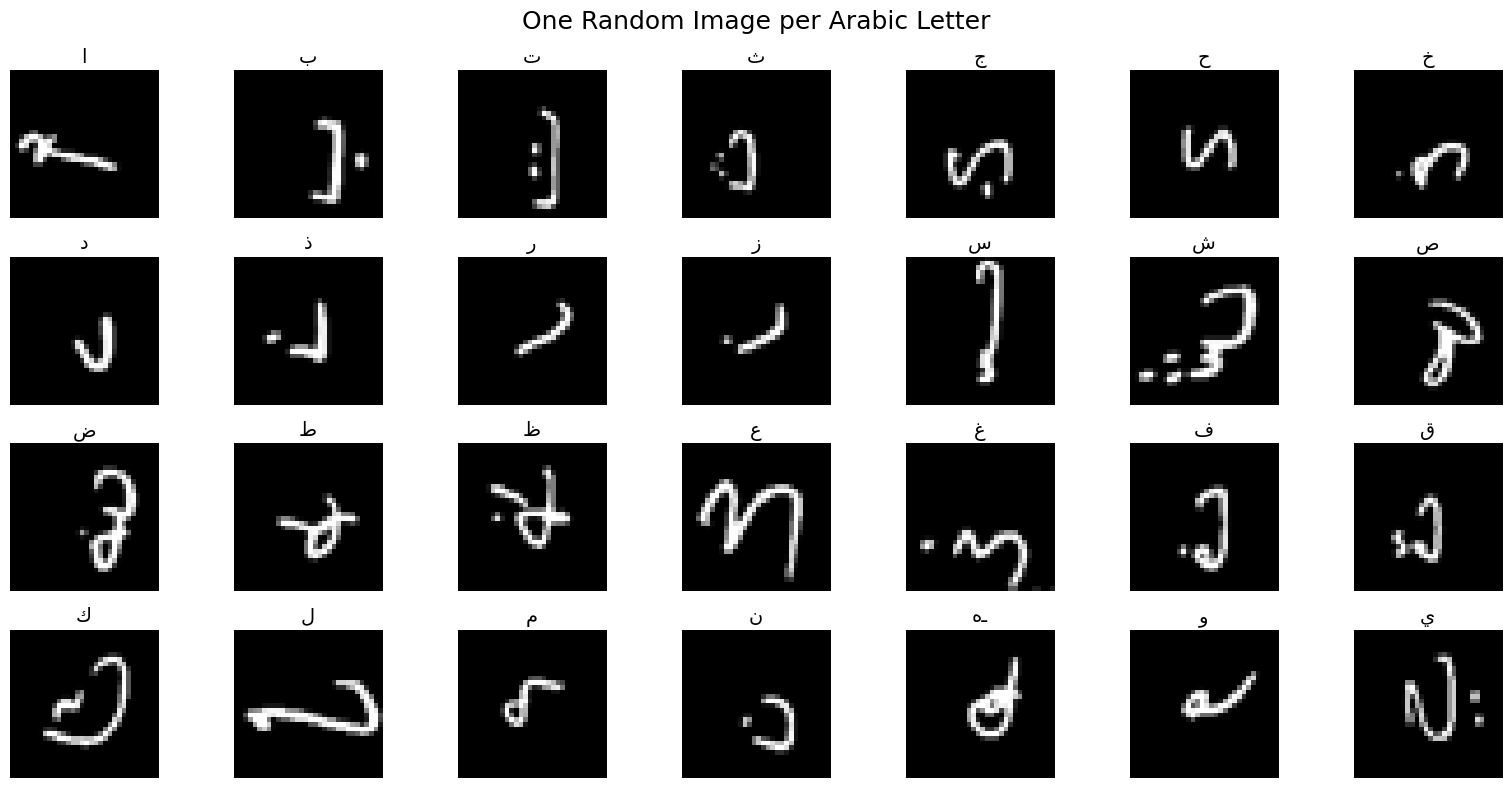

In [39]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Ensure y_train_letters exists
y_train_letters = y_train[0].map(label_to_letter)

# Create a DataFrame combining x_train and y_train_letters
df = x_train.copy()
df["label"] = y_train_letters

# Convert all pixel values to integers
df.iloc[:, :-1] = df.iloc[:, :-1].apply(pd.to_numeric)

# Get one random sample per unique letter
sampled_df = df.groupby("label").sample(n=1, random_state=42)

# Plot
plt.figure(figsize=(16, 8))
for i, (idx, row) in enumerate(sampled_df.iterrows()):
    img = row[:-1].values.astype(np.uint8).reshape(32, 32)  # Convert to uint8
    label = row["label"]
    plt.subplot(4, 7, i + 1)
    plt.imshow(img, cmap='gray')
    plt.title(f"{label}", fontsize=14)
    plt.axis("off")

plt.suptitle("One Random Image per Arabic Letter", fontsize=18)
plt.tight_layout()
plt.show()


The visual diversity in handwriting is noticeable .
- Some letters (like `ح`, `خ`, and `ج`) may appear visually similar, which could make classification more challenging.
- These samples confirm that the dataset includes a full set of Arabic characters, and that label-to-letter mapping is working correctly.

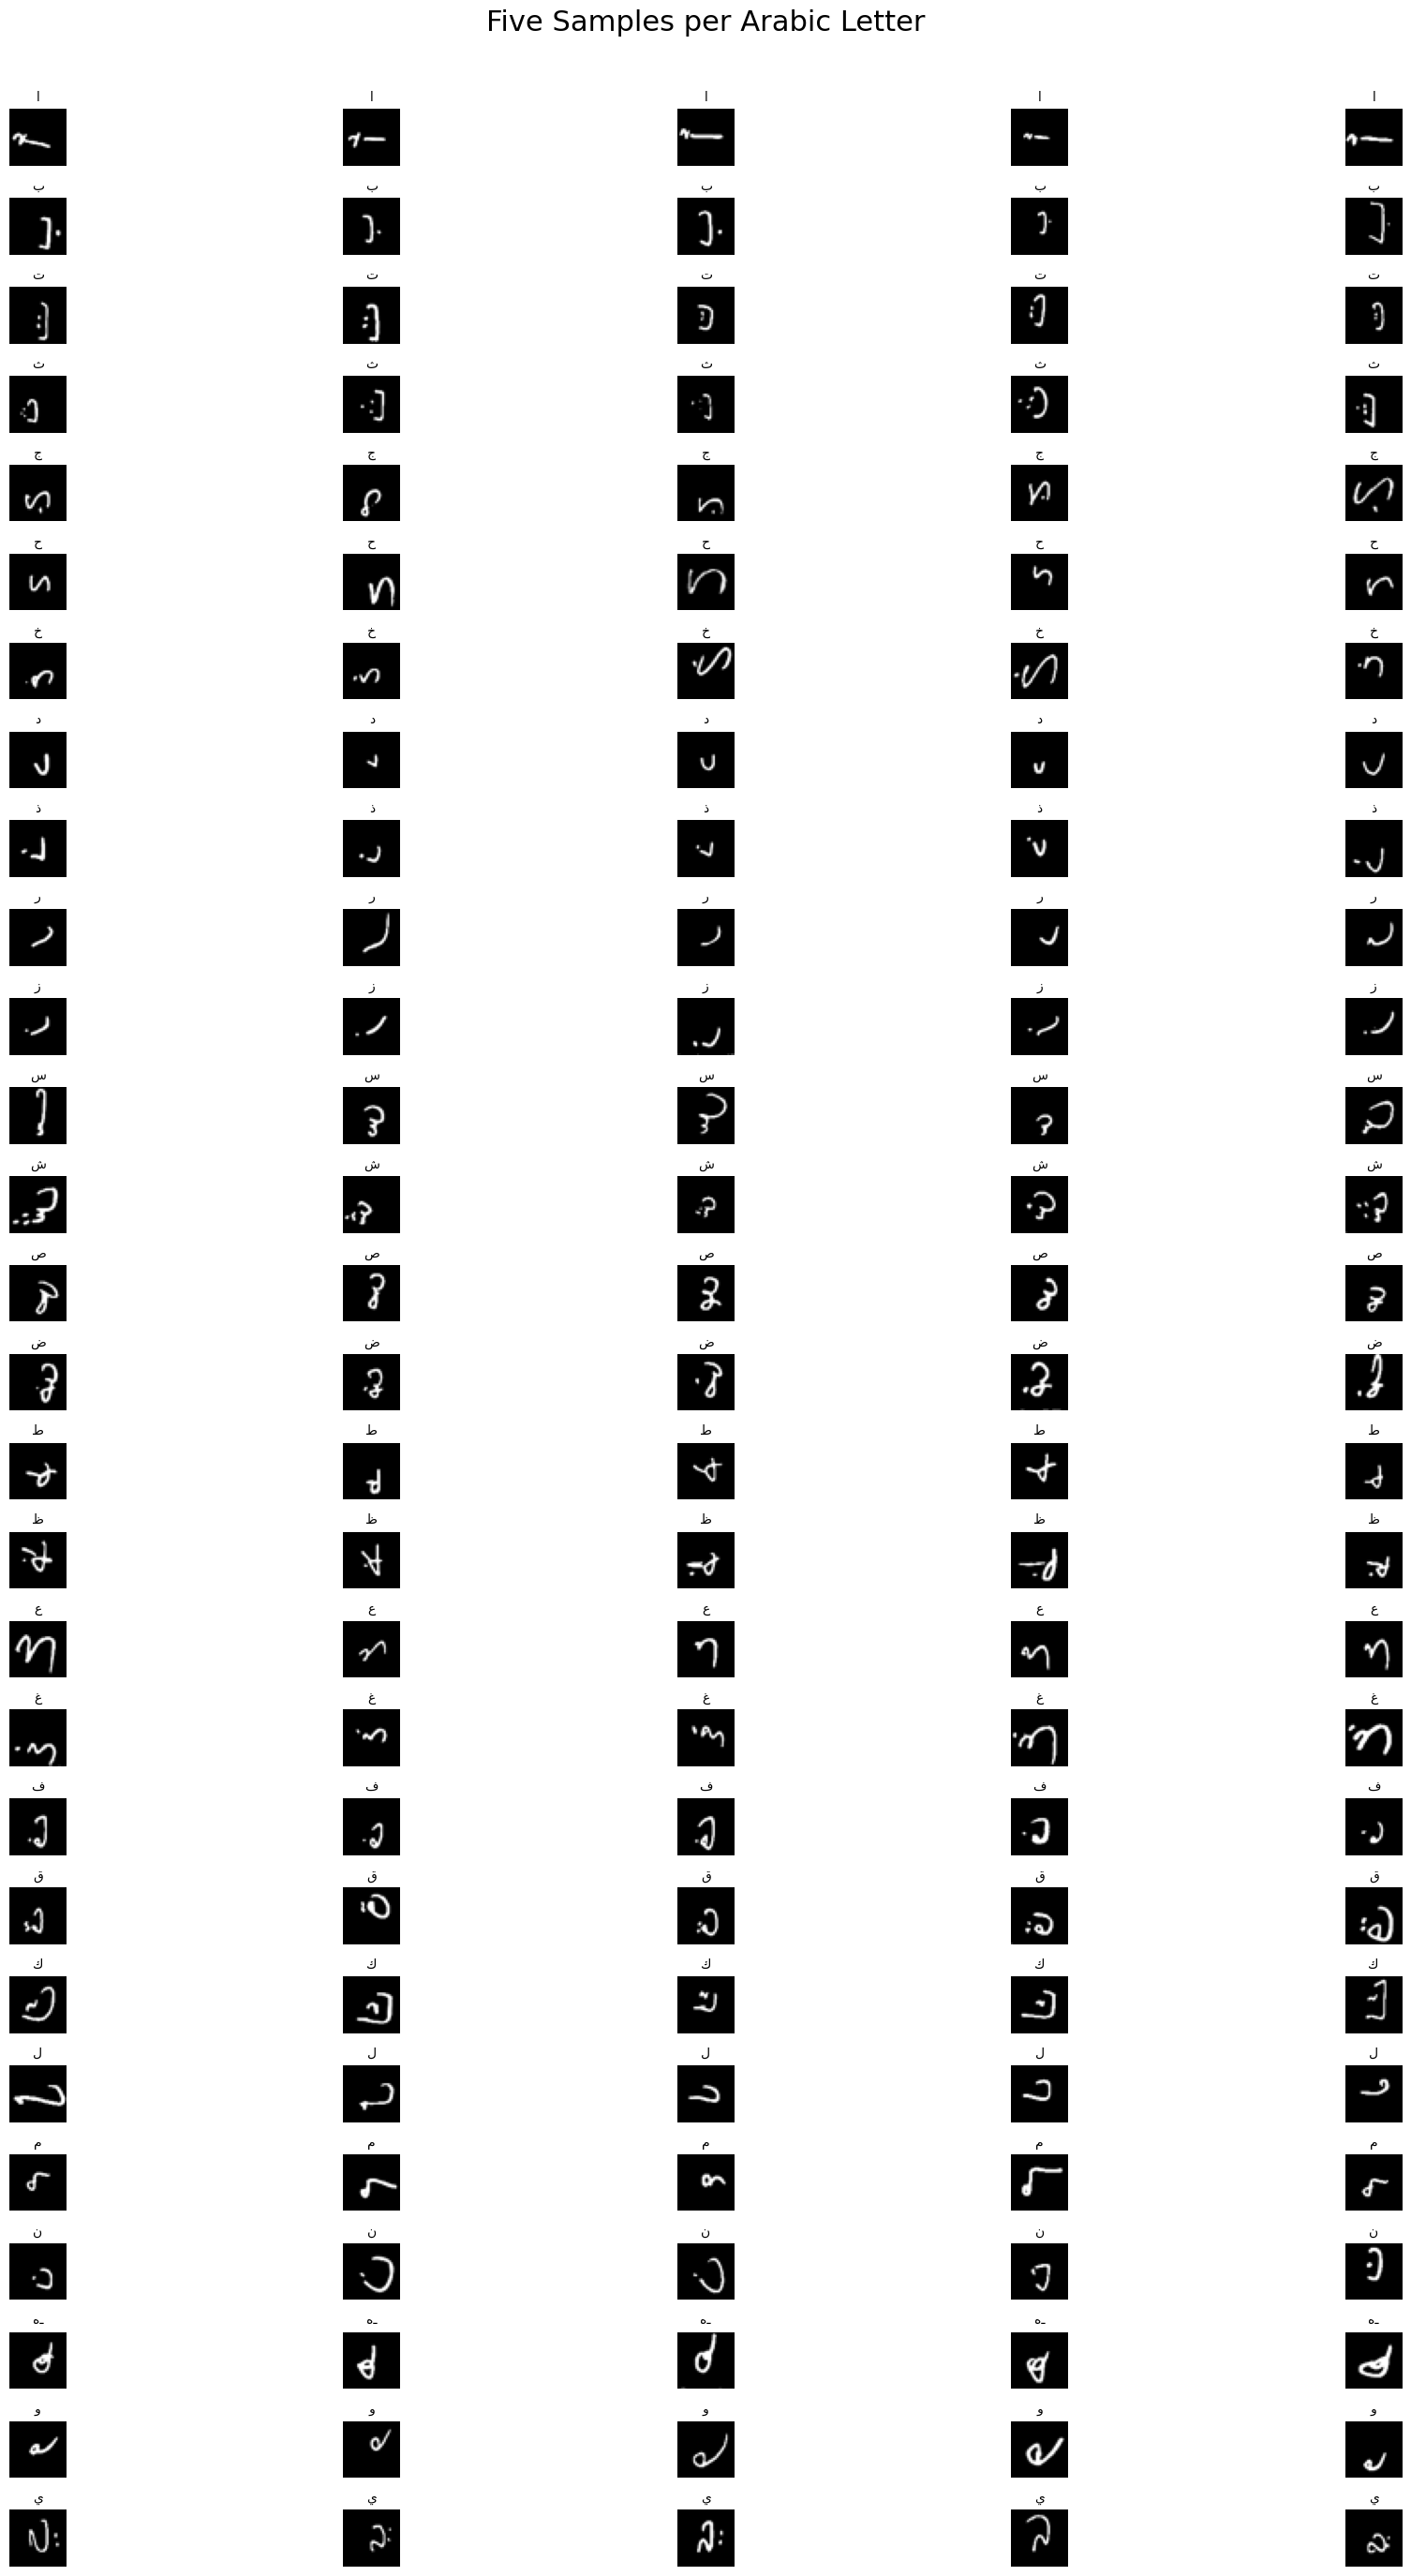

In [41]:
# Group by letter and sample 5 instances from each class
sampled_df = df.groupby("label").sample(n=5, random_state=42).reset_index(drop=True)

# Plot 5 samples per class (total 28x5 = 140 images)
plt.figure(figsize=(20, 28))
for i, (idx, row) in enumerate(sampled_df.iterrows()):
    img = row[:-1].astype(np.uint8).values.reshape(32, 32)
    label = row["label"]
    plt.subplot(28, 5, i + 1)
    plt.imshow(img, cmap='gray')
    plt.title(label, fontsize=10)
    plt.axis("off")

plt.suptitle("Five Samples per Arabic Letter", fontsize=22)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


Observation:

Shows clear variation in handwriting styles across all letters.

Similar-looking letters (e.g. `ح`, `خ`, `ج`) may be harder to distinguish.

Confirms dataset diversity — useful for training a robust model.


# **Running a "Raw" Model First**

Running a raw model first provides a valuable baseline and helps identify specific issues in the data, such as class confusion or noise.

This approach allows us to make informed decisions about preprocessing and data augmentation based on actual model performance, rather than assumptions.

We initially used LogisticRegression, but it was too slow for high-dimensional image data (1024 features per sample). So we switched to RandomForestClassifier:

In [43]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Train a faster model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(x_train, y_train.values.ravel())

# Predict on test set
y_pred = model.predict(x_test)

# Optional: see classification performance
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           1       0.76      0.95      0.84       120
           2       0.66      0.86      0.75       120
           3       0.54      0.57      0.56       120
           4       0.59      0.51      0.54       120
           5       0.74      0.67      0.70       120
           6       0.64      0.68      0.66       120
           7       0.64      0.57      0.60       120
           8       0.57      0.77      0.65       120
           9       0.61      0.58      0.60       120
          10       0.62      0.89      0.73       120
          11       0.71      0.61      0.65       120
          12       0.67      0.78      0.72       120
          13       0.81      0.66      0.72       120
          14       0.61      0.71      0.65       120
          15       0.78      0.52      0.62       120
          16       0.65      0.72      0.68       120
          17       0.66      0.53      0.59       120
          18       0.62    

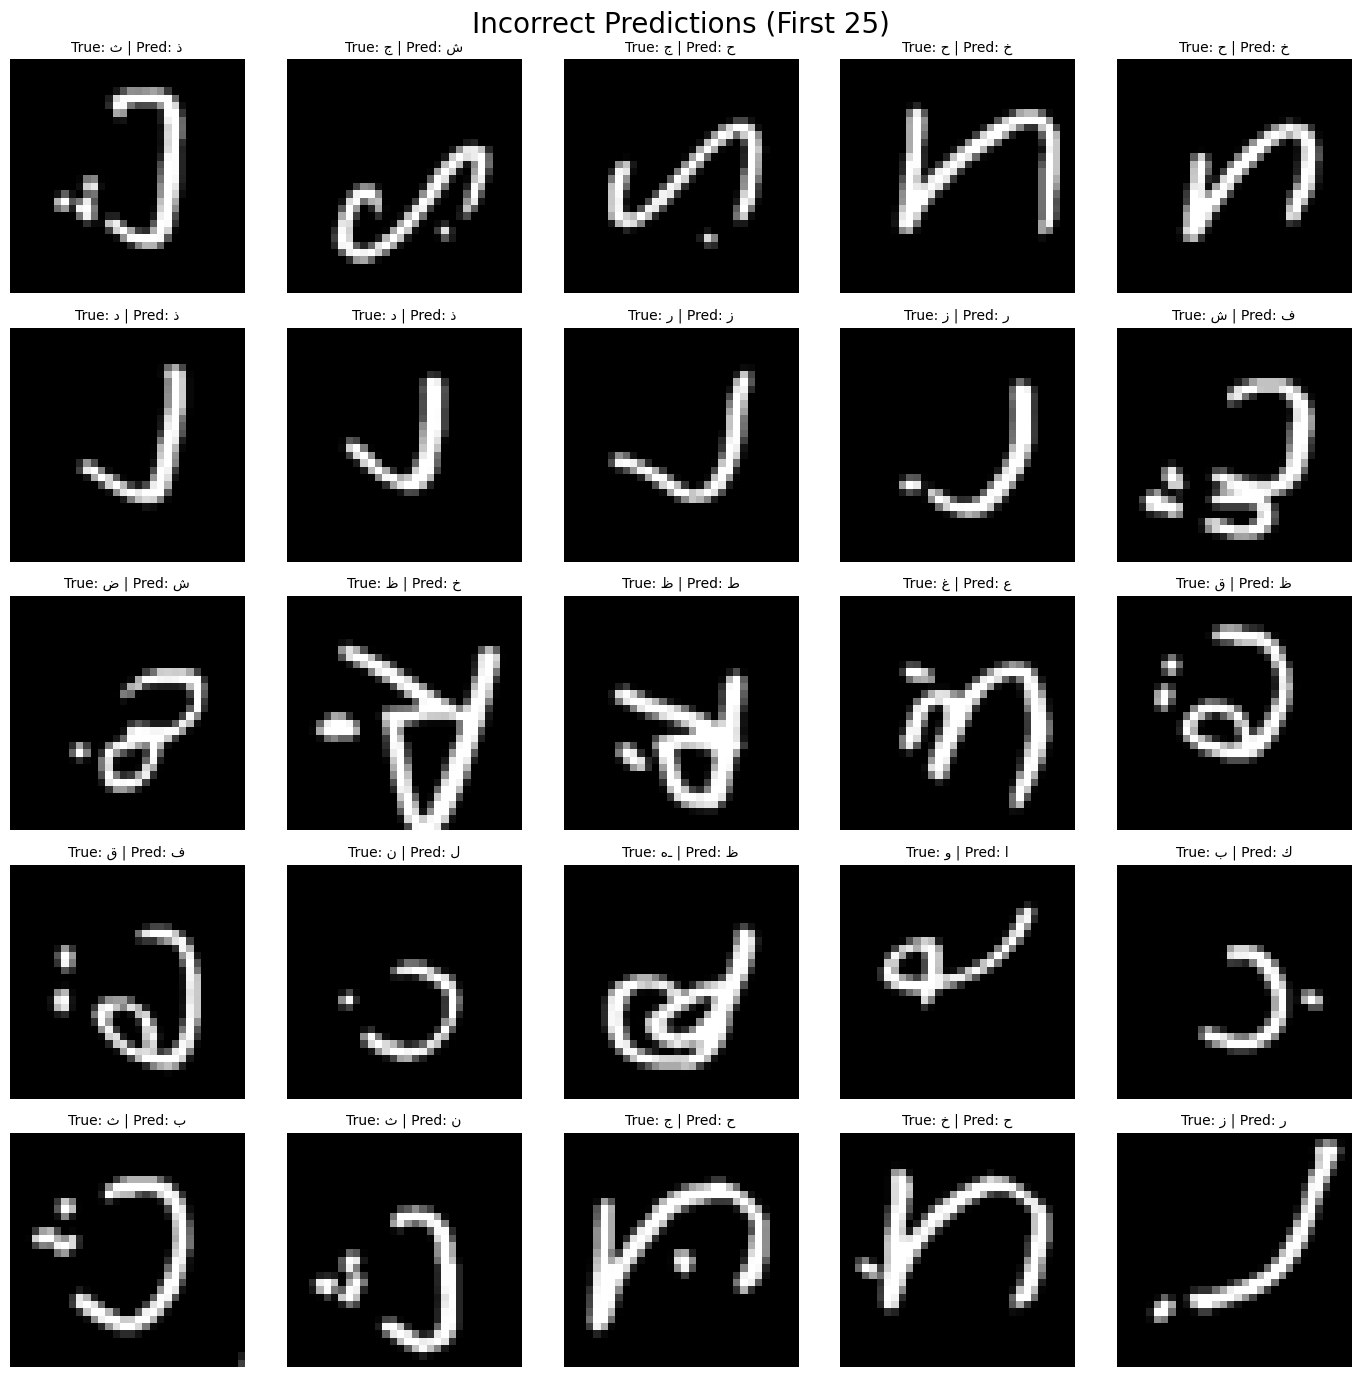

In [45]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Build test DataFrame with true and predicted labels
x_test_df = x_test.copy()
x_test_df["true_label"] = y_test[0].map(label_to_letter)
x_test_df["predicted_label"] = pd.Series(y_pred).map(label_to_letter)

# Filter incorrect predictions
wrong_preds = x_test_df[x_test_df["true_label"] != x_test_df["predicted_label"]]

# Plot 25 incorrect predictions
plt.figure(figsize=(14, 14))
for i, (idx, row) in enumerate(wrong_preds.head(25).iterrows()):
    img = row.iloc[:1024].astype(np.uint8).values.reshape(32, 32)
    true_label = row["true_label"]
    pred_label = row["predicted_label"]
    plt.subplot(5, 5, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title(f"True: {true_label} | Pred: {pred_label}", fontsize=10)
    plt.axis("off")

plt.suptitle("Incorrect Predictions (First 25)", fontsize=20)
plt.tight_layout()
plt.show()


# **From the confusion matrix and visualizations:**

# **Strengths:**

Some classes (e.g., 1, 10, 22, 23) are predicted with high precision and recall.

Accuracy of 68% is decent for a non-deep learning model on image data.

# **Weaknesses:**
Many confusions between visually similar characters, especially:

3 ↔ 4, 7 ↔ 9, 14 ↔ 18, etc.

Curved characters like ف ↔ ق, ص ↔ ض

Model lacks spatial awareness: reshaped pixel vectors (flattened 32x32) lose positional context.

# **Interpretation:**
The model appears to underfit classes with visually similar shapes, likely due to limited capacity in capturing spatial patterns.

This suggests the need for more advanced feature extraction techniques that can effectively model spatial hierarchies — an area where convolutional neural networks (CNNs) are particularly well-suited.

# **Preprocessing & Augmentation Plan**

In [47]:
import pandas as pd
from IPython.display import display, HTML

# Preprocessing plan
preprocessing_steps = [
    {
        "Step": "Normalize pixel values (/255.0)",
        "Why": "Scales pixel values to [0, 1], which speeds up convergence and stabilizes gradients."
    },
    {
        "Step": "One-hot encode labels",
        "Why": "Transforms integer class labels into binary vectors needed for categorical loss functions."
    },
    {
        "Step": "Reshape to (32, 32, 1)",
        "Why": "CNNs expect input with a channel dimension (grayscale = 1)."
    },
    {
        "Step": "Stratified train-test split",
        "Why": "Ensures each class is proportionally represented in both training and test sets."
    }
]

# Convert to DataFrame
df_pre = pd.DataFrame(preprocessing_steps)

# Display with better formatting
display(HTML(df_pre.to_html(index=False, escape=False)))


Step,Why
Normalize pixel values (/255.0),"Scales pixel values to [0, 1], which speeds up convergence and stabilizes gradients."
One-hot encode labels,Transforms integer class labels into binary vectors needed for categorical loss functions.
"Reshape to (32, 32, 1)",CNNs expect input with a channel dimension (grayscale = 1).
Stratified train-test split,Ensures each class is proportionally represented in both training and test sets.


In [49]:
# Augmentation plan
augmentation_steps = [
    {"Step": "rotation_range=10", "Why": "Simulates tilt in handwriting"},
    {"Step": "width_shift_range=0.1", "Why": "Mimics left/right writing variations"},
    {"Step": "height_shift_range=0.1", "Why": "Captures top/bottom misalignments"},
    {"Step": "shear_range=0.1", "Why": "Adds slant variability, common in handwriting"},
    {"Step": "zoom_range=0.1", "Why": "Simulates zoomed-in or out strokes"},
    {"Step": "horizontal_flip=False", "Why": "Arabic characters are directional"},
    {"Step": "vertical_flip=False", "Why": "Arabic has no upside-down variation"}
]

print("Augmentation Plan")
display(pd.DataFrame(augmentation_steps))

Augmentation Plan


,Step,Why
0,rotation_range=10,Simulates tilt in handwriting
1,width_shift_range=0.1,Mimics left/right writing variations
2,height_shift_range=0.1,Captures top/bottom misalignments
3,shear_range=0.1,"Adds slant variability, common in handwriting"
4,zoom_range=0.1,Simulates zoomed-in or out strokes
5,horizontal_flip=False,Arabic characters are directional
6,vertical_flip=False,Arabic has no upside-down variation


# **preprocessing**

In [51]:
# Normalize pixel values to [0, 1]
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

In [55]:
!pip install tensorflow


   ---------------------------------------- 0.0/376.0 MB ? eta -:--:--
    --------------------------------------- 7.3/376.0 MB 37.6 MB/s eta 0:00:10
   - -------------------------------------- 15.5/376.0 MB 37.4 MB/s eta 0:00:10
   -- ------------------------------------- 21.0/376.0 MB 33.9 MB/s eta 0:00:11
   --- ------------------------------------ 29.9/376.0 MB 35.7 MB/s eta 0:00:10
   ---- ----------------------------------- 38.5/376.0 MB 36.6 MB/s eta 0:00:10
   ----- ---------------------------------- 47.2/376.0 MB 37.1 MB/s eta 0:00:09
   ----- ---------------------------------- 56.1/376.0 MB 37.6 MB/s eta 0:00:09
   ------ --------------------------------- 65.0/376.0 MB 38.4 MB/s eta 0:00:09
   ------- -------------------------------- 74.2/376.0 MB 38.8 MB/s eta 0:00:08
   -------- ------------------------------- 82.8/376.0 MB 38.9 MB/s eta 0:00:08
   --------- ------------------------------ 91.8/376.0 MB 39.0 MB/s eta 0:00:08
   ---------- ---------------------------- 100.4/3

In [57]:
from tensorflow.keras.utils import to_categorical

# Convert class labels (1–28) to zero-based index (0–27)
y_train_adj = y_train[0] - 1
y_test_adj = y_test[0] - 1

# One-hot encode
y_train_oh = to_categorical(y_train_adj, num_classes=28)
y_test_oh = to_categorical(y_test_adj, num_classes=28)

In [59]:
# Reshape flattened 1024 vectors into 32x32 grayscale images
x_train_reshaped = x_train_norm.values.reshape(-1, 32, 32, 1)
x_test_reshaped = x_test_norm.values.reshape(-1, 32, 32, 1)

In [61]:
from sklearn.model_selection import train_test_split

# Stratified split from training set into train/val
x_train_final, x_val, y_train_final, y_val = train_test_split(
    x_train_reshaped, y_train_oh, test_size=0.2, stratify=y_train_adj, random_state=42
)

80% → actual training (x_train_final)

20% → validation (x_val)

In [63]:
# Check shapes
print("Train shape:", x_train_final.shape)
print("Val shape:", x_val.shape)

Train shape: (10752, 32, 32, 1)
Val shape: (2688, 32, 32, 1)


Data is correctly split (80/20), reshaped to (32, 32, 1).

In [65]:
# Value range check
print("Pixel range:", x_train_final.min(), "to", x_train_final.max())

Pixel range: 0.0 to 1.0


The pixel normalization is correct, as the range is [0.0, 1.0].

In [67]:
# Label check
print("Example one-hot label:", y_train_final[0])
print("One-hot sums (should all be 1):", y_train_final.sum(axis=1)[:5])

Example one-hot label: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0.]
One-hot sums (should all be 1): [1. 1. 1. 1. 1.]


The one-hot encoding is correct, as the example label has a single 1 and the sums of the one-hot labels are all 1.

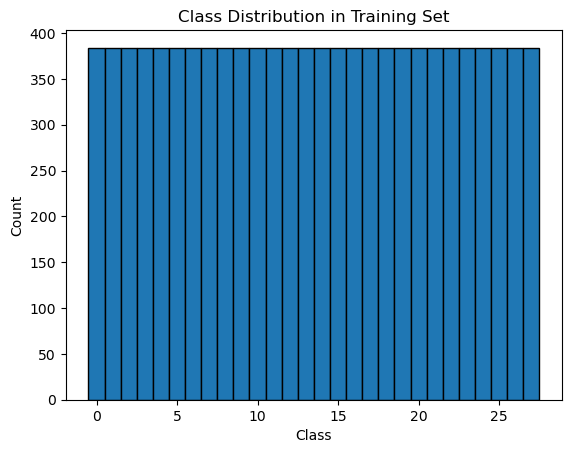

In [69]:
# Class balance
import numpy as np
import matplotlib.pyplot as plt

labels = np.argmax(y_train_final, axis=1)
plt.hist(labels, bins=np.arange(29)-0.5, edgecolor="black")
plt.title("Class Distribution in Training Set")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

The class distribution is as expected, with a balanced set of classes in the training data.

# **Data Augmentation**

In [71]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Initialize the ImageDataGenerator with the specified augmentation parameters
datagen = ImageDataGenerator(
    rotation_range=10,        # Simulates tilt in handwriting
    width_shift_range=0.1,    # Mimics left/right writing variations
    height_shift_range=0.1,   # Captures top/bottom misalignments
    shear_range=0.1,          # Adds slant variability
    zoom_range=0.1,           # Simulates zoomed-in or out strokes
    horizontal_flip=False,    # Arabic characters are directional
    vertical_flip=False       # Arabic has no upside-down variation
)

# Fit the datagen on the training data (this step is necessary for certain augmentations)
datagen.fit(x_train_final)


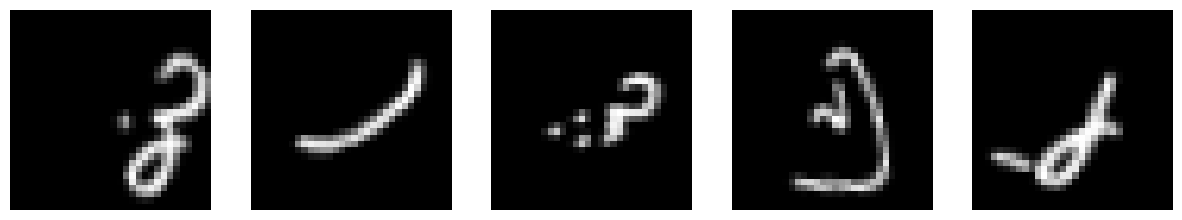

In [73]:
import matplotlib.pyplot as plt

# Example: Get a batch of augmented images
augmented_images = datagen.flow(x_train_final, y_train_final, batch_size=16)

# Plot a few augmented images
fig, axes = plt.subplots(1, 5, figsize=(15, 15))
for i, ax in enumerate(axes):
    ax.imshow(augmented_images[0][0][i].reshape(32, 32), cmap='gray')  # Adjust reshape if needed
    ax.axis('off')
plt.show()


# **CNN Model - Arabic character detection**

In [171]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Conv2D ,  Flatten , Dense , MaxPooling2D , Dropout , BatchNormalization , Input , Activation
from tensorflow.keras.layers import Add, Dropout, Flatten, Dense, GlobalAveragePooling2D
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping

The model architecture is a sequential model consisting of 10 layers. The initial layers are convolutional layers used to extract features from the input data. After the first two convolutional layers, a max pooling layer is added to reduce the dimensionality of the parameters, given that, without these two layers, the number of parameters exceeds 2 million. 
The output from the convolutional layers, which contains the extracted image features, is flattened to generate a feature vector. This feature vector is then passed to the dense layers, followed by a dropout layer to prevent overfitting. Finally, another dense layer is added to produce the classified output and uses a softmax activation function for classification.

In [77]:
def build_model():
    model = Sequential()
    model.add(Conv2D(32, (3 , 3), strides=(1, 1), activation='relu', input_shape=(32, 32, 1)))
    model.add(MaxPooling2D((2,2)))
    model.add(Conv2D(64 , (3 , 3) ,strides=(1 , 1), activation='relu' ))
    model.add(MaxPooling2D((2,2)))
    model.add(Conv2D(64 , (3 , 3) , activation= 'relu'))
    model.add(Flatten()) 
    model.add(Dense(512 , activation = 'relu'))
    model.add(Dense(256 , activation = 'relu'))
    model.add(Dropout(0.5))
    model.add(Dense(28 , activation = 'softmax')) 
    return model

In [113]:
def improved_model(): #Model 2
    model = Sequential()
    
    # Initial convolution with more filters
    model.add(Conv2D(64, (3, 3), padding='same', activation='relu', input_shape=(32, 32, 1)))
    model.add(BatchNormalization())
    model.add(Conv2D(64, (3, 3), padding='same', activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(0.2))
    
    # Second block with increased filters
    model.add(Conv2D(128, (3, 3), padding='same', activation='relu'))
    model.add(BatchNormalization())
    model.add(Conv2D(128, (3, 3), padding='same', activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(0.3))
    
    # Third block with even more filters for complex features
    model.add(Conv2D(256, (3, 3), padding='same', activation='relu'))
    model.add(BatchNormalization())
    model.add(Conv2D(256, (3, 3), padding='same', activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(0.4))
    
    # Fully connected layers
    model.add(Flatten())
    model.add(Dense(512, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.5))
    model.add(Dense(28, activation='softmax'))  # 28 Arabic letters
    
    return model

In [173]:
def residual_block(x, filters, kernel_size=3): #For model 3
    """Creates a residual block with two convolutional layers and a skip connection"""
    residual = x
    
    # If the input channels don't match the output channels, we need to project
    if residual.shape[-1] != filters:
        residual = Conv2D(filters, (1, 1), padding='same')(residual)
    
    # First convolutional layer
    x = Conv2D(filters, kernel_size, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    
    # Second convolutional layer
    x = Conv2D(filters, kernel_size, padding='same')(x)
    x = BatchNormalization()(x)
    
    # Add skip connection
    x = Add()([x, residual])
    x = Activation('relu')(x)
    
    return x

In [197]:
def more_improved_model():
    """Build an improved CNN with residual connections for Arabic character recognition"""
    inputs = Input(shape=(32, 32, 1))
    
    # Initial convolutional layer
    x = Conv2D(64, (3, 3), padding='same')(inputs)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    
    # First residual block
    x = residual_block(x, 64)
    x = MaxPooling2D((2, 2))(x)
    x = Dropout(0.1)(x)
    
    # Second residual block with more filters
    x = residual_block(x, 128)
    x = MaxPooling2D((2, 2))(x)
    x = Dropout(0.2)(x)
    
    # Third residual block with even more filters
    x = residual_block(x, 256)
    x = MaxPooling2D((2, 2))(x)
    x = Dropout(0.3)(x)
    
    # Global pooling and fully connected layers
    x = GlobalAveragePooling2D()(x)
    x = Dense(512)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(0.5)(x)
    
    # Output layer with 28 units for 28 Arabic characters
    outputs = Dense(28, activation='softmax')(x)
    
    model = Model(inputs=inputs, outputs=outputs)
    return model

In [199]:
#model = build_model()
#model = improved_model()
model = more_improved_model()

In [201]:
model.summary()

Model: "functional_35"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)    │ (None, 32, 32, 1)         │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_32 (Conv2D)            │ (None, 32, 32, 64)        │             640 │ input_layer_7[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_27        │ (None, 32, 32, 64)        │             256 │ conv2d_32[0][0]            │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_18 (Activation)    │ (None, 32, 32, 64)        │               0 │ batch_normalization_27[0]… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_33 (Conv2D)            │ (None, 32, 32, 64)        │          36,928 │ activation_18[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_28        │ (None, 32, 32, 64)        │             256 │ conv2d_33[0][0]            │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_19 (Activation)    │ (None, 32, 32, 64)        │               0 │ batch_normalization_28[0]… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_34 (Conv2D)            │ (None, 32, 32, 64)        │          36,928 │ activation_19[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_29        │ (None, 32, 32, 64)        │             256 │ conv2d_34[0][0]            │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add_6 (Add)                   │ (None, 32, 32, 64)        │               0 │ batch_normalization_29[0]… │
│                               │                           │                 │ activation_18[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_20 (Activation)    │ (None, 32, 32, 64)        │               0 │ add_6[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_11              │ (None, 16, 16, 64)        │               0 │ activation_20[0][0]        │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_13 (Dropout)          │ (None, 16, 16, 64)        │               0 │ max_pooling2d_11[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_36 (Conv2D)            │ (None, 16, 16, 128)       │          73,856 │ dropout_13[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_30        │ (None, 16, 16, 128)       │             51

 Total params: 1,374,364 (5.24 MB)

 Trainable params: 1,371,420 (5.23 MB)

 Non-trainable params: 2,944 (11.50 KB)

In [203]:
#model.compile(Adam(learning_rate = 1e-4) , loss = 'categorical_crossentropy' , metrics = ['accuracy'])
model.compile(
    optimizer=Adam(learning_rate=5e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy', tf.keras.metrics.F1Score(name='f1_score')])

In [183]:
early_stopping = EarlyStopping(
    monitor = 'val_loss',
    patience =3 ,
    restore_best_weights = True
)

In [209]:
reduce_lr = ReduceLROnPlateau( #For model 4
    monitor='val_loss',
    factor=0.2,
    patience=5,
    min_lr=1e-6,
    mode='min',
    verbose=1
)

In [211]:
history = model.fit(augmented_images , epochs = 50 , validation_data = (x_val , y_val) , callbacks = [reduce_lr)

Epoch 1/50
672/672 ━━━━━━━━━━━━━━━━━━━━ 59s 88ms/step - accuracy: 0.7621 - f1_score: 0.7576 - loss: 1.3628 - val_accuracy: 0.8404 - val_f1_score: 0.8380 - val_loss: 1.2378 - learning_rate: 5.0000e-04
Epoch 2/50
672/672 ━━━━━━━━━━━━━━━━━━━━ 59s 88ms/step - accuracy: 0.8656 - f1_score: 0.8629 - loss: 1.1226 - val_accuracy: 0.8702 - val_f1_score: 0.8710 - val_loss: 1.1574 - learning_rate: 5.0000e-04
Epoch 3/50
672/672 ━━━━━━━━━━━━━━━━━━━━ 62s 92ms/step - accuracy: 0.9067 - f1_score: 0.9053 - loss: 1.0155 - val_accuracy: 0.9576 - val_f1_score: 0.9577 - val_loss: 0.9068 - learning_rate: 5.0000e-04
Epoch 4/50
672/672 ━━━━━━━━━━━━━━━━━━━━ 79s 88ms/step - accuracy: 0.9303 - f1_score: 0.9273 - loss: 0.9419 - val_accuracy: 0.9342 - val_f1_score: 0.9342 - val_loss: 0.9543 - learning_rate: 5.0000e-04
Epoch 5/50
672/672 ━━━━━━━━━━━━━━━━━━━━ 59s 88ms/step - accuracy: 0.9330 - f1_score: 0.9308 - loss: 0.9280 - val_accuracy: 0.9594 - val_f1_score: 0.9594 - val_loss: 0.8629 - learning_rate: 5.0000e-04


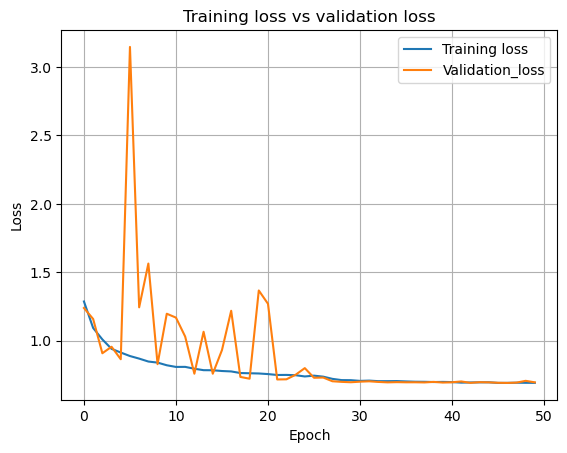

In [213]:
loss = history.history['loss']
val_loss = history.history['val_loss']
plt.plot(loss , label = 'Training loss')
plt.plot(val_loss , label = 'Validation_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training loss vs validation loss')
plt.legend()
plt.grid()
plt.show()

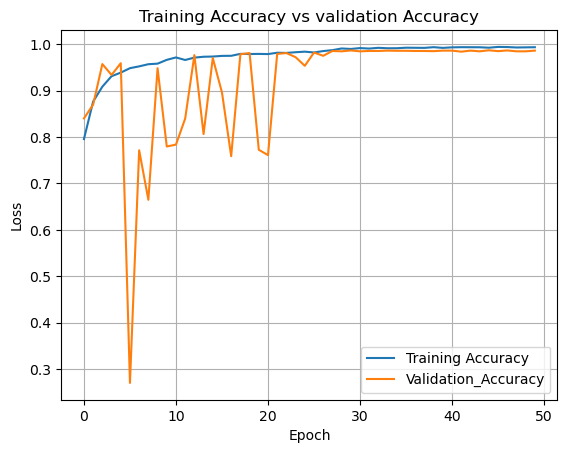

In [215]:
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
plt.plot(accuracy , label = 'Training Accuracy')
plt.plot(val_accuracy , label = 'Validation_Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Accuracy vs validation Accuracy')
plt.legend()
plt.grid()
plt.show()

In [217]:
import numpy as np
predictions = model.predict(x_test_reshaped , batch_size= 1)
predictions = np.argmax(predictions,axis = 1)

3360/3360 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step


In [219]:
y_test = np.argmax(y_test_oh, axis=1)

In [225]:
loss , accuracy , _ = model.evaluate(x_test_reshaped , y_test_oh)
print(f"Test loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")
#print(f"Test F1 score: {f1_score:.4f}")

105/105 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - accuracy: 0.9852 - f1_score: 0.9811 - loss: 0.7065
Test loss: 0.6963
Test Accuracy: 0.9869


In [233]:
model.save('early_birds_model.h5')

In [ ]:
#so we can load it later 'its on my laptop' 
#from tensorflow.keras.models import load_model

#loaded_model = load_model('my_cnn_model.h5')

In [227]:
from sklearn.metrics import classification_report , confusion_matrix , ConfusionMatrixDisplay

print(classification_report(y_test , predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       120
           1       1.00      1.00      1.00       120
           2       0.98      0.99      0.98       120
           3       0.99      0.99      0.99       120
           4       0.99      1.00      1.00       120
           5       0.99      0.99      0.99       120
           6       1.00      0.99      1.00       120
           7       0.98      0.98      0.98       120
           8       0.99      0.95      0.97       120
           9       0.95      0.99      0.97       120
          10       0.97      0.95      0.96       120
          11       1.00      0.98      0.99       120
          12       0.99      1.00      1.00       120
          13       0.96      1.00      0.98       120
          14       1.00      0.97      0.98       120
          15       0.96      1.00      0.98       120
          16       1.00      0.96      0.98       120
          17       1.00    

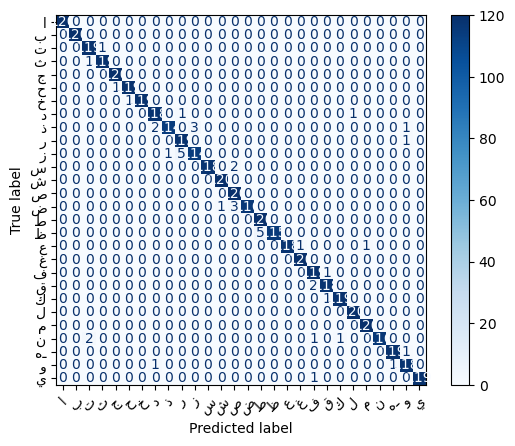

In [229]:
cm = confusion_matrix(y_test , predictions)
ConfusionMatrixDisplay(cm, display_labels=list(label_to_letter.values())).plot(cmap="Blues", xticks_rotation=45)

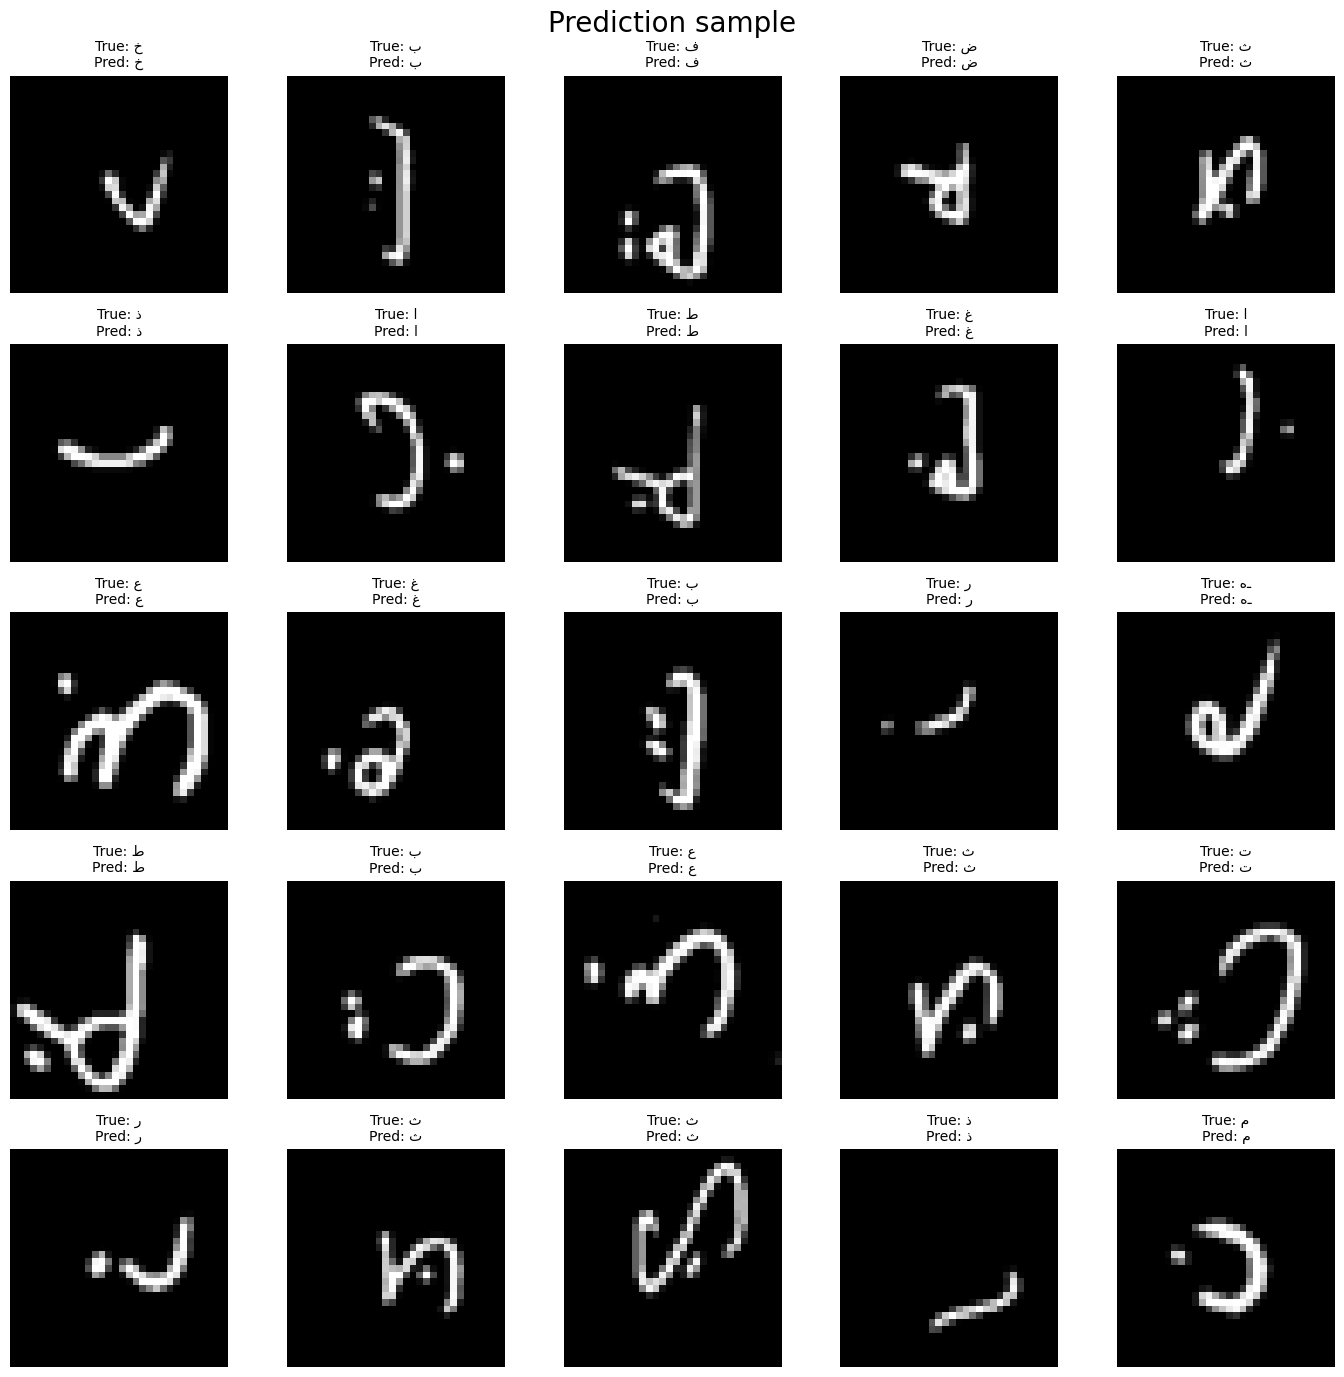

In [231]:
x_test_df = x_test.copy()
x_test_df["true_label"] = pd.Series(y_test).map(label_to_letter)
x_test_df["predicted_label"] = pd.Series(predictions).map(label_to_letter)

random_preds = x_test_df.sample(n=25, random_state=0)  

plt.figure(figsize=(14, 14))
for i, (idx, row) in enumerate(random_preds.iterrows()):
    img = row.iloc[:1024].astype(np.uint8).values.reshape(32, 32)
    true_label = row["true_label"]
    pred_label = row["predicted_label"]
    
    plt.subplot(5, 5, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title(f"True: {true_label}\nPred: {pred_label}", fontsize=10)
    plt.axis("off")

plt.suptitle("Prediction sample", fontsize=20)
plt.tight_layout()
plt.show()


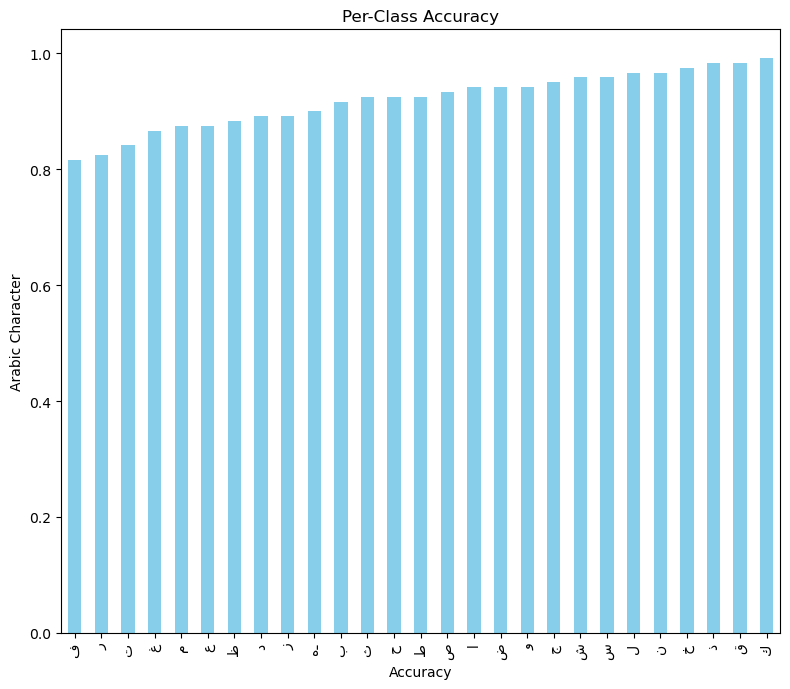

In [105]:
#we add another column to the dataset that holds the boolean value of whether the prediction was correct
#this step is crucial to get the per-class accuracy
x_test_df["correct"] = x_test_df["true_label"] == x_test_df["predicted_label"]

class_accuracy = x_test_df.groupby("true_label")["correct"].mean().sort_values()

plt.figure(figsize=(8, 7))
class_accuracy.plot(kind="bar", color="skyblue")
plt.title("Per-Class Accuracy")
plt.xlabel("Accuracy")
plt.ylabel("Arabic Character")
#plt.grid(axis='y')
plt.tight_layout()
plt.show()


In [169]:
#dropped the first 2 columns because there were non values 
x_test_df = x_test_df.drop(x_test_df.columns[:2], axis=1)